# Simulación Monte Carlo - Proceso de Poisson y Colisiones en RACH


## Introducción

El proceso de Poisson es una herramienta fundamental para modelar la llegada de eventos aleatorios en el tiempo.
En sistemas LTE/5G, los dispositivos (UEs) intentan acceder al canal RACH de forma aleatoria, lo que puede provocar colisiones.

En este notebook se utiliza simulación Monte Carlo para modelar las colisiones y las llegadas organizadas por el proceso de Poisson.



## Datos del problema

- Tasa de llegada: λ = 8 UE/ms
- Número de simulaciones: 1,000,000
- Número de preámbulos: P = 64
- Distribución de llegadas: Proceso de Poisson



## Marco Teórico

Un proceso de Poisson modela la cantidad de eventos aleatorios en un intervalo fijo de tiempo, donde los eventos ocurren de forma independiente con una tasa promedio constante λ. Su distribución viene dada por P(N = k) = e^{-λ} * λ^k / k!, entendiendo que los siguientes elementos actúan en base a estas funciones:
* e−λ es lo que controla la probabilidad base
* λ^k nos indica el crecimiento según eventos
* k! es la normalización

En el caso de la probabilidad de colisión condicional, esta se obtiene calculando primero la probabilidad de que todos los usuarios seleccionen preámbulos distintos. A medida que cada nuevo usuario elige un preámbulo, disminuye el número de opciones disponibles sin colisión. Este proceso se modela como un producto de probabilidades decrecientes, donde cada término representa la probabilidad de elegir un preámbulo no utilizado. Finalmente, la probabilidad de colisión se obtiene como el complemento de la probabilidad de no colisión. Este proceso se ve representado por la siguiente fórmula:

P(colisión | N = k) = 1 - ∏(1 - i/P)



*Resumen de fórmulas*:

Distribución de Poisson que sigue la fórmula:

P(N = k) = e^{-λ} * λ^k / k!

Probabilidad de colisión condicional:

P(colisión | N = k) = 1 - ∏(1 - i/P)

# 00- Prepación de la simulación

Paso 1: Importar las librerias
Paso 2: Base de Parámetros iniciales

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [2]:

lam = 8
P = 64
simulaciones = 10**6

N_samples = np.random.poisson(lam, simulaciones)


##  01- Distribución Empírica de UEs 


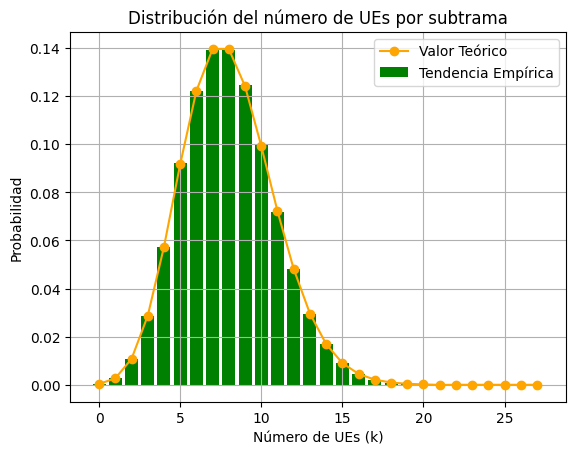

In [ ]:
counts = np.bincount(N_samples)
probs_emp = counts / simulaciones

k_values = np.arange(len(probs_emp))


probs_teo = [(np.exp(-lam) * lam**k) / math.factorial(k) for k in k_values]
probs_emp

plt.figure()
plt.bar(k_values, probs_emp, color='green', label='Tendencia Empírica')
plt.plot(k_values, probs_teo, color='orange', marker='o', label='Valor Teórico')

plt.xlabel("Número de UEs (k)")
plt.ylabel("Probabilidad")
plt.title("Distribución del número de UEs por subtrama")
plt.legend()
plt.grid()

plt.show()

# Observaciones 
La gráfica muestra la distribución empírica del número de usuarios que intentan acceder al canal RACH en cada subtrama, obtenida mediante simulación Monte Carlo. Esta se compara con la distribución teórica de Poisson con parámetro λ = 8.

Se observa una alta coincidencia entre ambas curvas, lo que valida que el proceso de llegadas está adecuadamente modelado por una distribución de Poisson. La mayor probabilidad se concentra alrededor de valores cercanos a λ, mientras que valores extremos (muy bajos o muy altos) presentan menor frecuencia.


## 02-  Probabilidad de Colisión

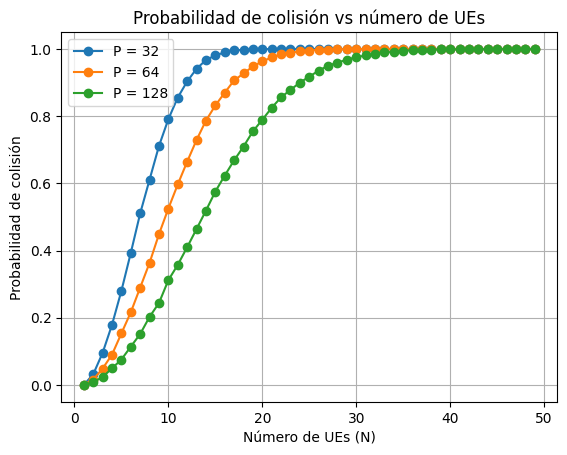

In [19]:
def prob_colision_condicional(N, P, simulaciones=20000):
    colisiones = 0
    
    for _ in range(simulaciones):
        elecciones = np.random.randint(0, P, size=N)
        if len(np.unique(elecciones)) < N:
            colisiones += 1
    
    return colisiones / simulaciones


N_values = range(1, 50)
P_values = [32, 64, 128]

plt.figure()

for P in P_values:
    probs = [prob_colision_condicional(N, P) for N in N_values]
    plt.plot(N_values, probs, marker='o', label=f'P = {P}')

plt.xlabel("Número de UEs (N)")
plt.ylabel("Probabilidad de colisión")
plt.title("Probabilidad de colisión vs número de UEs")
plt.legend()
plt.grid()

plt.show()

# Observaciones 

La gráfica muestra la probabilidad de que ocurra al menos una colisión de preámbulos en función del número de usuarios (N), considerando distintos valores del número de preámbulos disponibles (P).

Se observa que la probabilidad de colisión aumenta rápidamente a medida que crece el número de usuarios, debido al incremento en el número de combinaciones posibles entre ellos. Este crecimiento es no lineal y responde a una tendencia similar a la paradoja del cumpleaños.

Además, al aumentar el número de preámbulos (P), la probabilidad de colisión disminuye y la curva se desplaza hacia la derecha, lo que indica que el sistema puede soportar un mayor número de usuarios antes de que las colisiones se vuelvan significativas.


# 03- Comparación del error entre modelos

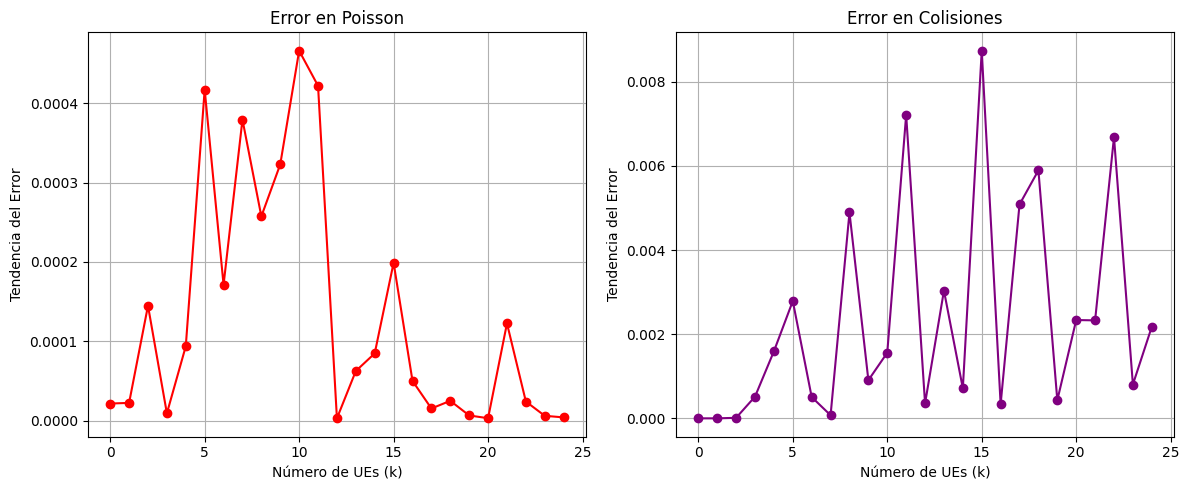

In [40]:

# Definir rango
k_range = range(0, 25)

def colision_simulada(k, P, sim=10000):
    if k <= 1:
        return 0
    
    colisiones = 0
    for _ in range(sim):
        elecciones = np.random.randint(0, P, size=k)
        if len(np.unique(elecciones)) < k:
            colisiones += 1
    
    return colisiones / sim


def colision_teorica(k, P):
    if k <= 1:
        return 0
    
    prod = 1
    for i in range(k):
        prod *= (1 - i/P)
    
    return 1 - prod

col_sim = [colision_simulada(k, P) for k in k_range]
col_teo = [colision_teorica(k, P) for k in k_range]


error_col = np.abs(np.array(col_sim) - np.array(col_teo))

fig, axs = plt.subplots(1, 2, figsize=(12,5))


error_poisson = np.abs(np.array(probs_emp) - np.array(probs_teo))

axs[0].plot(k_values[:25], error_poisson[:25], color='red', marker='o')
axs[0].set_title("Error en Poisson")
axs[0].set_xlabel("Número de UEs (k)")
axs[0].set_ylabel("Tendencia del Error")
axs[0].grid()

# Error colisiones
axs[1].plot(k_range, error_col, color='purple', marker='o')
axs[1].set_title("Error en Colisiones")
axs[1].set_xlabel("Número de UEs (k)")
axs[1].set_ylabel("Tendencia del Error")
axs[1].grid()

plt.tight_layout()
plt.show()


## Observaciones


Esta comparación muestra que las simulaciones Monte Carlo reproducen con buena precisión los valores teóricos tanto del proceso de Poisson como de la probabilidad de colisión. 

El error observado es bajo, lo que indica que el modelo de llegadas y la formulación de colisiones son consistentes. Las ligeras diferencias se deben al carácter aleatorio de la simulación y al número finito de iteraciones.

En particular, el comportamiento de las colisiones refleja que la probabilidad de coincidencia aumenta rápidamente incluso con un número moderado de usuarios.



## Relación con la paradoja del cumpleaños

El problema de colisiones en el canal RACH es análogo a la paradoja del cumpleaños, donde se analiza la probabilidad de que dos personas compartan la misma fecha de nacimiento.
En este caso:

* Los UEs representan las personas
* Los preámbulos (P = 64) representan los días del año
* Una colisión equivale a compartir cumpleaños

En ambos problemas, la probabilidad de coincidencia crece rápidamente debido al aumento en el número de pares posibles, aproximadamente proporcional a la fórmula N(N−1)​/2

Esto explica por qué, incluso con un número moderado de usuarios, las colisiones se vuelven altamente probables.


## Conclusiones

* La simulación confirma que las llegadas de usuarios siguen una distribución de Poisson con λ = 8, representando adecuadamente el comportamiento aleatorio del sistema.

* Los resultados de Monte Carlo coinciden con los valores teóricos, validando el modelo utilizado.

* Se observa que la probabilidad de colisión aumenta rápidamente incluso con un número moderado de usuarios, debido a la variabilidad del proceso y al crecimiento combinatorio de posibles coincidencias.

* Este comportamiento es análogo a la paradoja del cumpleaños, donde un número relativamente pequeño de elementos genera una alta probabilidad de coincidencia.

* En consecuencia, las colisiones son un fenómeno relevante en el RACH, lo que resalta la importancia de mecanismos eficientes de acceso en redes LTE/5G.

Realizado por Kassey Tavárez ID 1015-2171